Load Data

In [1]:
import torch
from data_split import load_data, concat_datasets
import numpy as np
import random

seed = 2025
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
rng = np.random.default_rng(seed)
torch.cuda.manual_seed_all(seed)

dataset_name = "Zeisel_p20_p29"
setting = "setting1"

omics = 1

omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood, gene_name =load_data(dataset_name, setting, omics=1)
if omics1_test_id_loader is None:
    omics1_mixed_loader = omics1_test_ood_loader
else:
    omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
    all_data_loader = concat_datasets(omics1_train_loader, omics1_mixed_loader)

print(f'ID: {global_categories_id}')
print(f'OOD: {global_categories_ood}')
print(f'Mapping OOD: {mapping_ood}')

print(len(global_categories_id))

[INFO] Split Train and Test Data by Batch: Train: ['p20']
[INFO] Split Train and Test Data by Batch: Test: ['p29']


Index(['Astrocytes', 'Cerebellum neurons',
       'Cholinergic and monoaminergic neurons', 'Choroid epithelial cells',
       'Di- and mesencephalon excitatory neurons',
       'Di- and mesencephalon inhibitory neurons', 'Ependymal cells',
       'Glutamatergic neuroblasts', 'Hindbrain neurons', 'Microglia',
       'Oligodendrocyte precursor cells', 'Oligodendrocytes',
       'Peptidergic neurons', 'Pericytes',
       'Peripheral sensory neurofilament neurons',
       'Peripheral sensory non-peptidergic neurons',
       'Peripheral sensory peptidergic neurons', 'Perivascular macrophages',
       'Satellite glia', 'Schwann cells', 'Spinal cord excitatory neurons',
       'Spinal cord inhibitory neurons',
       'Subcommissural organ hypendymal cells',
       'Subventricular zone radial glia-like cells',
       'Vascular and leptomeningeal cells', 'Vascular endothelial cells',
       'Vascular smooth muscle cells'],
      dtype='object')
ID: Index(['Astrocytes', 'Cerebellum neurons',
   

Initialize the model

In [2]:
from scDiscovery_architecture import *
import torch.optim as optim

class_number = len(global_categories_id)

device = torch.device("cuda:3")

omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]

E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

Contrastive-Reconstruction Representation Learning (CRRL)

In [3]:
from scDiscovery_architecture import Decoder
from algorithm_utils import train_decoder_classification_single_omics

D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)

optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)

E_rna, D_rna, Classifier = train_decoder_classification_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs=5, device=device)


Epoch [1/5], CLS Loss: 1.1488, RNA Recon Loss: 8.1362, RNA KL Loss: 0.2357, Acc_train: 78.09, Acc_test: 76.30
Epoch [2/5], CLS Loss: 0.3771, RNA Recon Loss: 6.9528, RNA KL Loss: 0.2678, Acc_train: 95.74, Acc_test: 88.80
Epoch [3/5], CLS Loss: 0.1625, RNA Recon Loss: 5.9424, RNA KL Loss: 0.2914, Acc_train: 99.21, Acc_test: 90.42
Epoch [4/5], CLS Loss: 0.0787, RNA Recon Loss: 5.0444, RNA KL Loss: 0.2995, Acc_train: 99.29, Acc_test: 90.74
Epoch [5/5], CLS Loss: 0.0511, RNA Recon Loss: 4.1949, RNA KL Loss: 0.3052, Acc_train: 99.57, Acc_test: 90.59


Adaptive Decision Boundary Calibration (ADBC)

=================== Before Calibration ===================


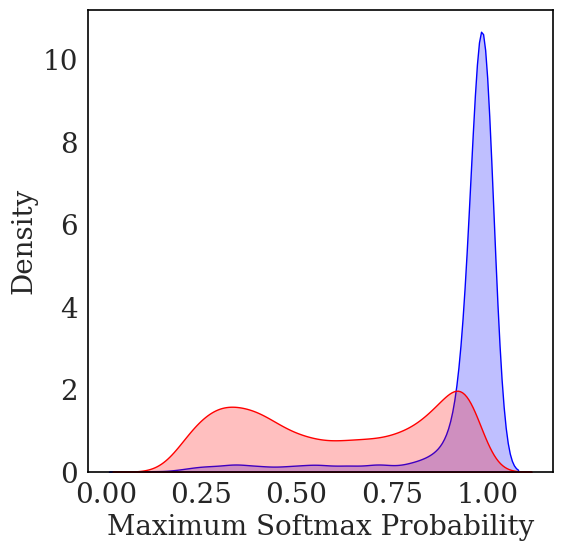

Final threshold used: 0.8
Detected OOD samples: 12059
Detected ID samples: 4089
=================== After Calibration ===================


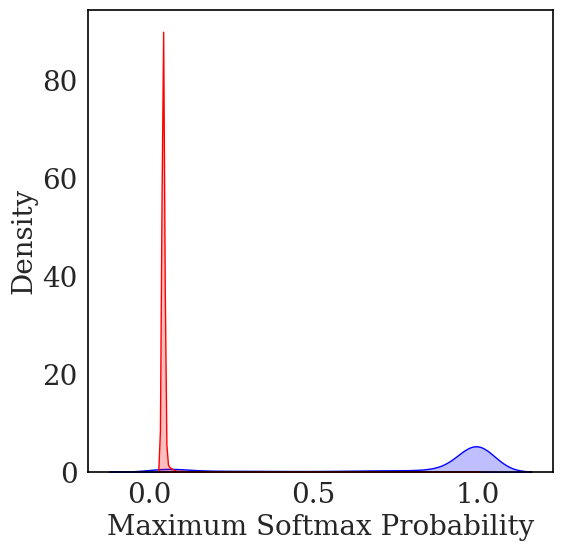

Final threshold used: 0.1
Detected OOD samples: 11214
Detected ID samples: 4934
=================== ROC Curve ===================


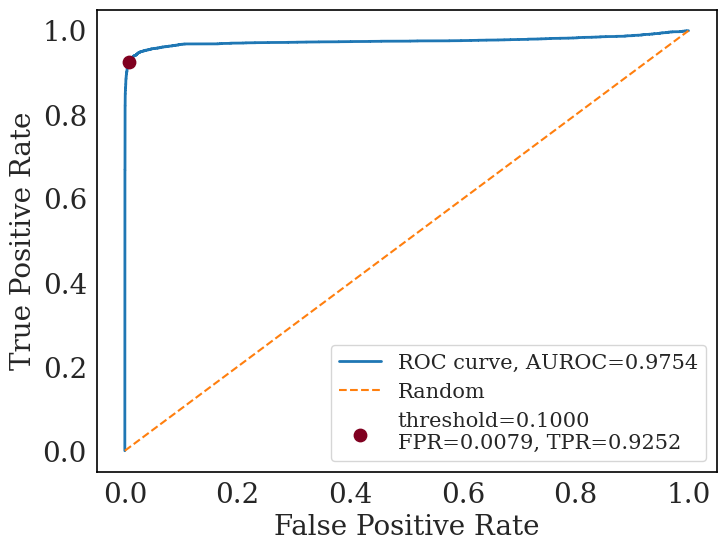

In [4]:
from calibration import adaptive_decision_boundary_calibration

optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)

scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

threshold, filtered_omics1_ood_loader, filtered_omics1_id_loader = adaptive_decision_boundary_calibration(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader,omics1_test_id_loader, omics1_test_ood_loader, omics1_mixed_loader, class_number, device, dataset_name, setting, num_iters=1, num_epochs=5, recall_level=0.95)

Dynamic Novel Cell Type Expansion (DNCTE)

In [5]:
from dynamic_expansion import dynamic_novel_cell_type_expansion

adata, E_rna, D_rna, Classifier_expanded = dynamic_novel_cell_type_expansion(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, scheduler_E_rna, scheduler_D_rna, filtered_omics1_ood_loader, omics1_train_loader, omics1_test_id_loader, omics1_mixed_loader, gene_name, class_number, num_epochs=5, device=device)

Epoch [1/5], CLS Loss: 0.7972, RNA Recon Loss: 2.5829, RNA KL Loss: 0.3562, Acc_train: 95.97, Acc_test: 85.94
Epoch [2/5], CLS Loss: 0.1457, RNA Recon Loss: 2.1687, RNA KL Loss: 0.3428, Acc_train: 98.76, Acc_test: 86.77
Epoch [3/5], CLS Loss: 0.0665, RNA Recon Loss: 1.9912, RNA KL Loss: 0.3437, Acc_train: 99.45, Acc_test: 86.26
Epoch [4/5], CLS Loss: 0.0414, RNA Recon Loss: 1.8824, RNA KL Loss: 0.3406, Acc_train: 99.70, Acc_test: 86.81
Epoch [5/5], CLS Loss: 0.0294, RNA Recon Loss: 1.7786, RNA KL Loss: 0.3382, Acc_train: 99.80, Acc_test: 86.24


Evaluation

In [6]:
from metrics import evaluate_ncd_discovery_potential, calculate_discovery_asw

metrics = evaluate_ncd_discovery_potential(
    adata=adata,
    y_true='y_true_with_unknown',
    y_pred='y_pred_with_unknown',
    embed_key='X_scDiscovery',
    unknown_label='Unknown'
)

for k, v in metrics.items():
    print(f"{k}: {v}")

Multi-F1: 0.9388077122198517
Multi-Accuracy: 0.9551647262818925
F1: 0.9729657387580299
Precision: 0.9476016684045881
Recall: 0.9997249724972497


In [7]:
from metrics import evaluate_model_on_novel_clas

metrics_ood, _, recon_data_ood, y_true_ood, y_pred_ood, Emb_ood = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_ood_loader, device)

print("Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

Metrics:
ARI: 0.8570921126816967
AMI: 0.8754118980452233
NMI: 0.8756748135134359
HOM: 0.9702182348706304


Visualization

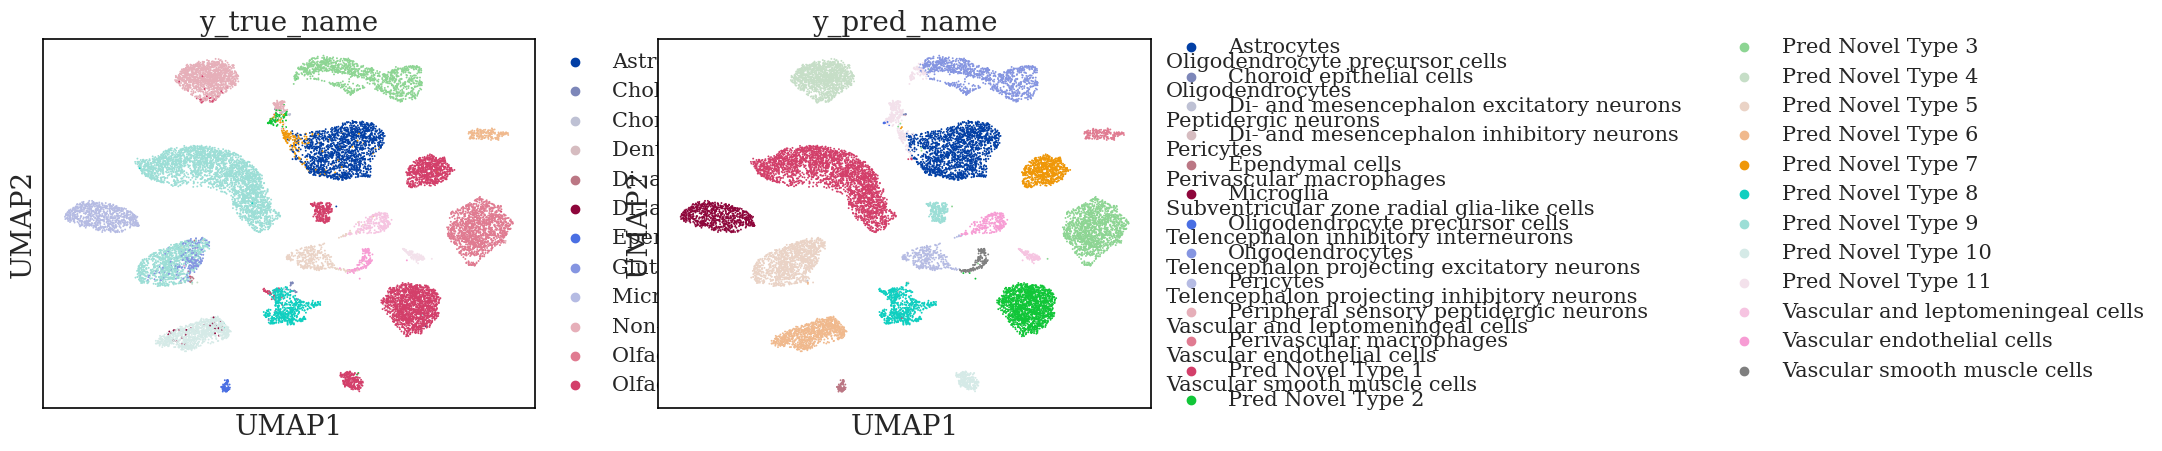

In [8]:
import scanpy as sc
from dynamic_expansion import cell_type_mapping

adata = cell_type_mapping(adata, global_categories_id, mapping_ood)

sc.pp.neighbors(adata, use_rep='X_scDiscovery', metric="cosine")
sc.tl.umap(adata)

sc.pl.umap(adata, color=['y_true_name', 'y_pred_name'], save=f"_scDiscovery_umap_label_{dataset_name}_{setting}.png")  # legend_loc='on data', 